# Plot configuration of Fresno 4-12-2026, 14-47-14 Winner Datatset

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd


sns.set_context("paper", font_scale=1.4)

data = pd.read_csv("training_history.csv")
data.head()

,epoch,train_loss,test_loss
0,1,0.378283,0.085141
1,2,0.300880,0.182069
2,3,0.239598,0.330664
3,4,0.262453,0.310894
4,5,0.254039,0.251036


### Loss Curves

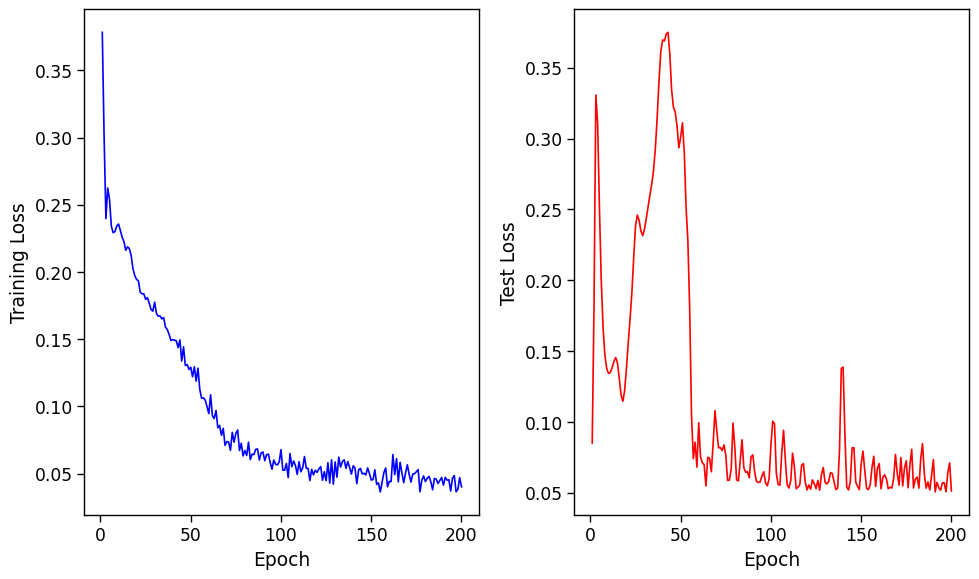

In [2]:
# Plotting the training and validation loss
fig, ax = plt.subplots(figsize=(10, 6), nrows = 1, ncols = 2)
sns.lineplot(data = data, x = "epoch", y = "train_loss", ax=ax[0], color="blue")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training Loss")
sns.lineplot(data, x="epoch", y="test_loss", ax=ax[1], color="red")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Test Loss")
plt.tight_layout()
plt.show()


### Prediction Curve

In [3]:
# Predictions
trainingset = pd.read_csv("true_vs_pred_train.csv")
testset = pd.read_csv("true_vs_pred_test.csv")
trainingset.tail()

,sample_index,true_train,pred_train
48,48,1.677800,1.956701
49,49,1.887525,1.877252
50,50,2.621562,2.078898
51,51,2.202112,1.708289
52,52,1.141881,1.195931


In [4]:
testset["sample_index"] = testset["sample_index"] + 53
testset.head()

,sample_index,true_test,pred_test
0,53,1.245688,1.074860
1,54,1.245688,1.278409
2,55,0.830459,1.303666
3,56,1.245688,1.307951
4,57,1.349495,1.349689


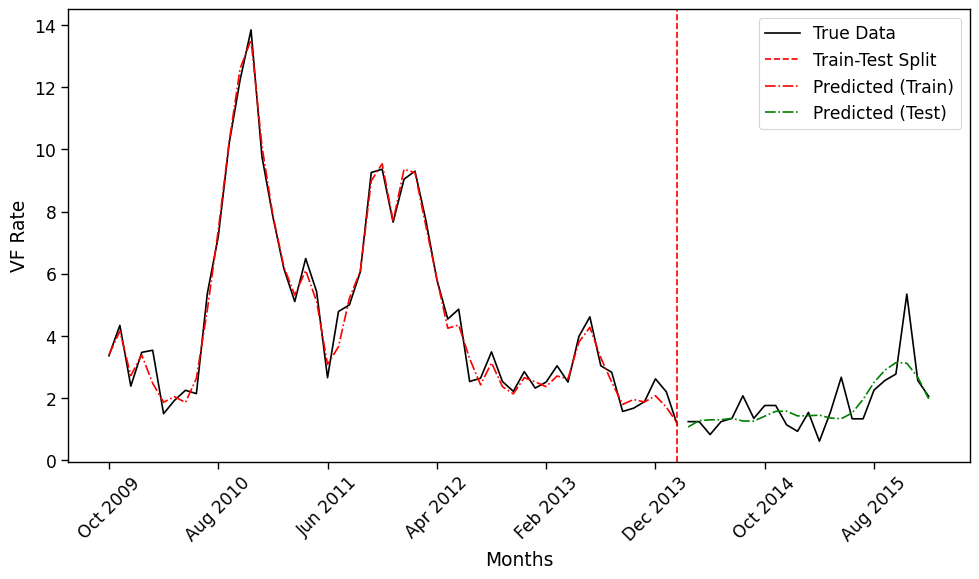

In [5]:
plt.figure(figsize=(10,6))
ax = sns.lineplot(data=trainingset, x="sample_index", y="true_train", color="black", label="True Data")
ax.axvline(x=52, color='red', linestyle='--', label="Train-Test Split")
sns.lineplot(data=testset, x="sample_index", y="true_test", color="black", label="_truedata")
sns.lineplot(data=trainingset, x="sample_index", y="pred_train", linestyle="-.", color='red', label="Predicted (Train)")
sns.lineplot(data=testset, x="sample_index", y="pred_test", linestyle="-.", color="green", label="Predicted (Test)")
plt.legend()
# 1. Create the date range to match your 75 samples
dates = pd.date_range(start='2009-10-01', periods=75, freq='MS')


# 2. Select every 10th index
tick_indices = list(range(0, 75, 10))

# 3. Format the labels (e.g., 'Oct 2009', 'Aug 2010', etc.)
tick_labels = [dates[i].strftime('%b %Y') for i in tick_indices]

# 4. Apply to your plot
plt.xticks(tick_indices, tick_labels, rotation=45)
ax.set_xlabel("Months")
ax.set_ylabel("VF Rate")
plt.tight_layout()

### PFI Chart

In [6]:
# pfi data
pfi_data = pd.read_csv("pfi_importance.csv")
pfi_data

,Feature,Importance,window_size
0,FIRE_Acres_Burned,0.079103,12
1,PRECIP,0.024449,11
2,WIND_EventCount,0.008693,5
3,WIND_AvgMPH,0.197550,6
4,WIND_RunMiles,0.041949,4
5,AQI_PM25,-0.009745,7
6,AQI_PM10,0.446414,5
7,EARTHQUAKE_Total,-0.000131,1
8,PESTICIDE_Total,0.102667,6
9,RODENTICIDE_Total,0.020645,1


<Axes: xlabel='Importance', ylabel='Feature'>

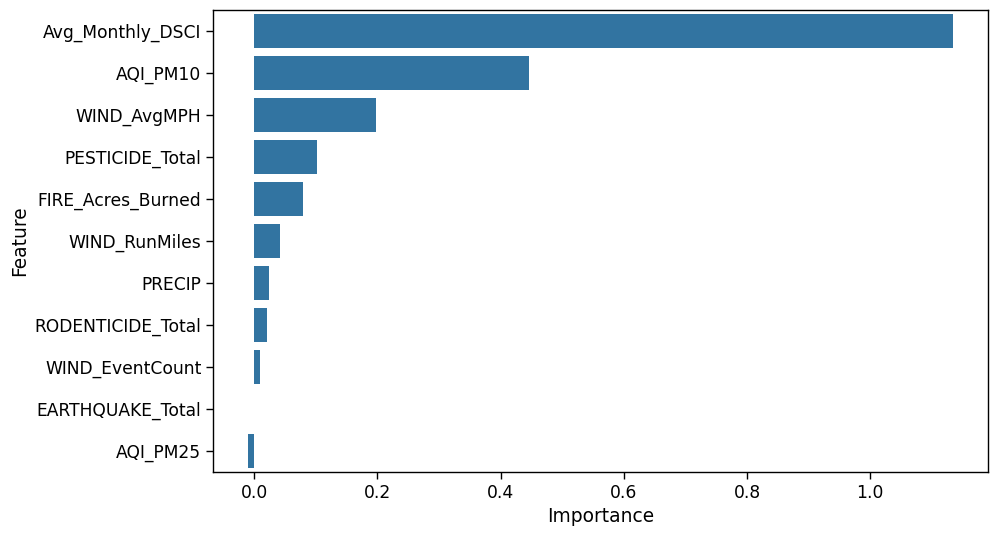

In [7]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=pfi_data.sort_values(by="Importance", ascending=False))

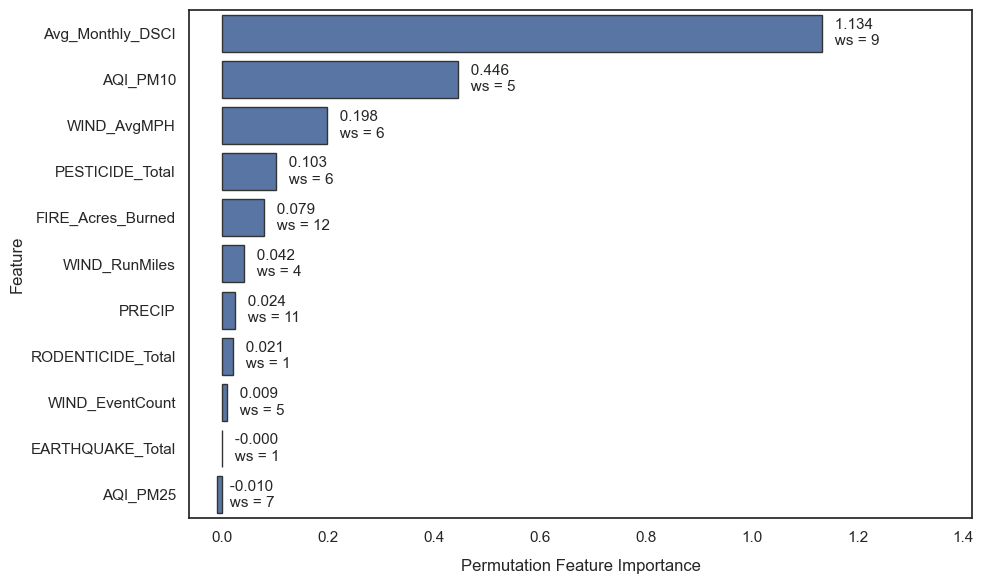

In [8]:
# 1. Slice for top 5
ranked_features = pfi_data.sort_values(by="Importance", ascending=False)

# 2. Setup Plot
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create Barplot
# We use a muted color and thin edges for a professional look
bars = sns.barplot(
    x="Importance", 
    y="Feature", 
    data=ranked_features, 
    color="#4C72B0", 
    edgecolor=".2"
)

# 4. Annotate values to the right of the bars
for i, (index, row) in enumerate(ranked_features.iterrows()):
    imp = row['Importance']
    ws = int(row['window_size'])
    
    # Format the string: Importance value and Window Size abbreviation
    label = f"   {imp:.3f}\n   ws = {ws}"
    
    # Place text at the end of each bar
    ax.text(
        x = imp,            # Start text at the end of the bar
        y = i,              # Vertical center of the bar
        s = label,          # The string to print
        va = 'center',      # Vertical alignment
        ha = 'left',        # Horizontal alignment (starts to the right of x)
        fontsize = 11,
        fontweight = 'medium'
    )

# 5. Final Polish for Publication
ax.set_xlabel("Permutation Feature Importance", fontsize=12, labelpad=10)
ax.set_ylabel("Feature") 
ax.set_xlim(ranked_features['Importance'].min()*1.25 -.05 , ranked_features['Importance'].max() * 1.25) # Add padding for labels

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Y')

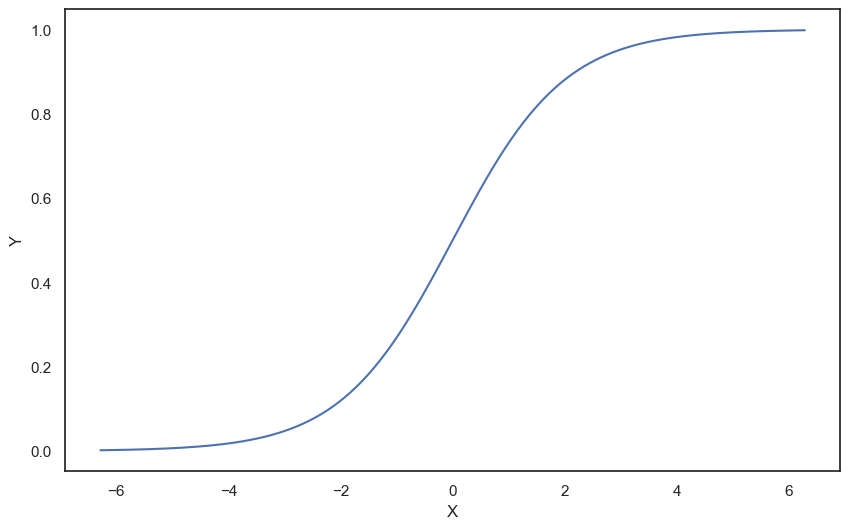

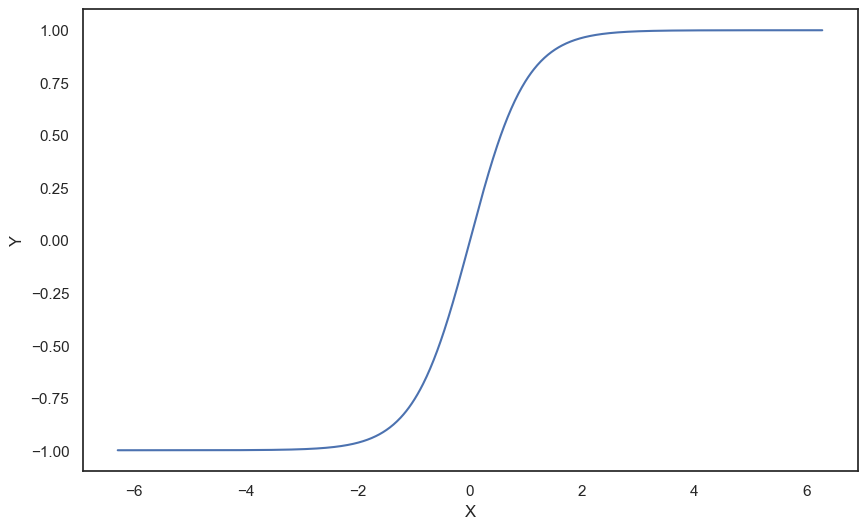

In [9]:
# random sigmoid graph 
sigmoid = lambda x: 1/(1 + np.exp(-1.0*x))
x = np.linspace(-2*np.pi, 2*np.pi, 1000)

plt.figure(figsize=(10,6))
ax = sns.lineplot(x=x, y=sigmoid(x))
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.figure(figsize=(10,6))
ax = sns.lineplot(x=x, y=np.tanh(x))
ax.set_xlabel("X")
ax.set_ylabel("Y")

In [10]:
featxforms = pd.read_csv("../fresno_Rat_Drought_feattransformed_2026-04-12_19-08-31/true_vs_pred_test.csv")
allxforms  = pd.read_csv("../fresno_Rat_Drought_feattransformed_vfrate_2026-04-12_19-26-58/true_vs_pred_test.csv")

In [11]:
rmse_func = lambda x: np.sqrt(np.mean((x["pred_test"] - x["true_test"])**2))

noxform_rmse = rmse_func(testset)
featxforms_rmse = rmse_func(featxforms)
allxforms_rmse  = rmse_func(allxforms)

print(f"No Transforms: {noxform_rmse:.3f}\nFeature Transforms: {featxforms_rmse:.3f}\nAll Transforms: {allxforms_rmse:.3f}")

No Transforms: 0.650
Feature Transforms: 0.780
All Transforms: 0.271


<Axes: xlabel='None', ylabel='Count'>

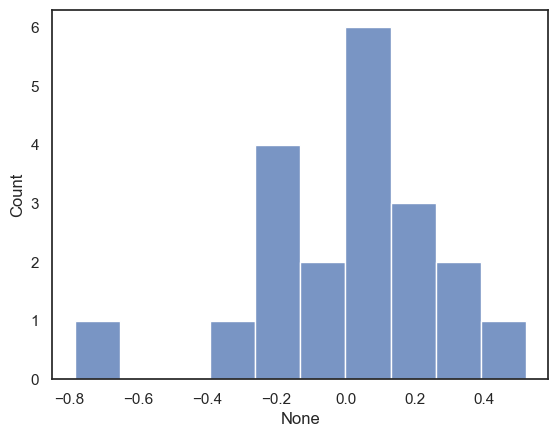

In [12]:
log1perrors = allxforms["pred_test"] - allxforms["true_test"]
plt.Figure(figsize=(10,6))
sns.histplot(x=log1perrors, bins=10)

RMSE unxformed: 0.9400677162004375


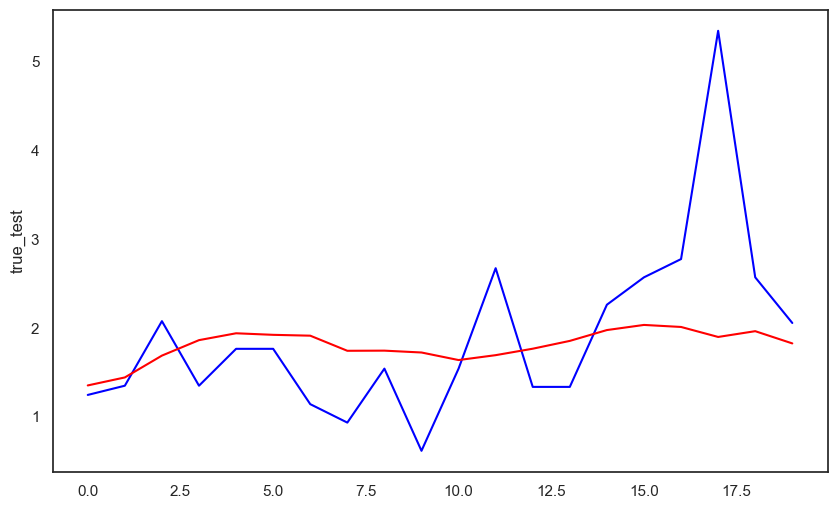

In [15]:
# plotting the log1p re-transformed predictions
unxformed_trues = np.exp(allxforms["true_test"]) - 1
unxformed_preds = np.exp(allxforms["pred_test"]) - 1
plotticks = np.arange(0, len(unxformed_trues), 1)

plt.figure(figsize=(10,6))
sns.lineplot(x=plotticks, y=unxformed_trues, color="blue")
sns.lineplot(x=plotticks, y=unxformed_preds, color="red")
print(f"RMSE unxformed: {np.sqrt(np.mean((unxformed_preds - unxformed_trues)**2))}")